In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("speedvsAccvsThrottle.csv").dropna()

# Adjust resolution if needed
acc_bins = np.linspace(df.acceleration.min(), df.acceleration.max(), 81)   # 80 intervals
speed_bins = np.linspace(df.speed.min(), df.speed.max(), 81)

# Assign bins
df["acc_bin"] = np.digitize(df["acceleration"], acc_bins) - 1
df["speed_bin"] = np.digitize(df["speed"], speed_bins) - 1

# Initialize LUT
lut = np.zeros((len(acc_bins), len(speed_bins)))

for ai in range(len(acc_bins)):
    for si in range(len(speed_bins)):
        grp = df[(df.acc_bin == ai) & (df.speed_bin == si)]
        if len(grp) > 0:
            # average throttle that produced that acceleration at that speed
            lut[ai, si] = grp.throttle.mean()
        else:
            lut[ai, si] = 0.0  # safe fallback


In [ ]:
with open("accel_to_throttle_lut.h", "w") as f:
    f.write("#pragma once\n\n")
    f.write(f"const int ACC_BINS = {len(acc_bins)};\n")
    f.write(f"const int SPEED_BINS = {len(speed_bins)};\n\n")

    f.write("const float ACC_TO_THROTTLE_LUT[ACC_BINS][SPEED_BINS] = {\n")

    for row in lut:
        row_str = ", ".join(f"{val:.5f}" for val in row)
        f.write(f"    {{{row_str}}},\n")

    f.write("};\n")

# Polynomial Fit


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import joblib

# Load CSV
df = pd.read_csv("speedvsAccvsThrottle.csv")

X = df[['acceleration', 'speed']].values
y = df['throttle'].values

# Choose the polynomial degree
degree = 2   # 2 is usually enough; 3 if highly nonlinear

poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

joblib.dump((model.coef_, model.intercept_, degree), "poly2.pkl")

print("Model trained.")
print("coef size:", len(model.coef_))


Model trained.
coef size: 6


In [ ]:
import joblib
from itertools import combinations_with_replacement

coef, intercept, degree = joblib.load("poly2.pkl")

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree)
poly.fit(np.zeros((1,2)))  # just to get feature names

feature_names = poly.get_feature_names_out(['a', 'v'])

def generate_cpp_poly_2d(coef, intercept, feature_names):
    cpp = "double throttle_from_acc_speed(double a, double v) {\n"
    cpp += f"    return {intercept:.12f}"

    for c, term in zip(coef[1:], feature_names[1:]):  # skip bias
        cpp += f" + ({c:.12f} * ({term}))"
    cpp += ";\n}\n"

    # cpp = cpp.replace(" ", " * ")

    return cpp

cpp_code = generate_cpp_poly_2d(coef, intercept, feature_names)

with open("throttle_model.cpp", "w") as f:
    f.write(cpp_code)

print(cpp_code)


double throttle_from_acc_speed(double a, double v) {
    return -0.027589244474 + (0.000584383964 * (a)) + (0.063858337965 * (v)) + (0.000658518079 * (a^2)) + (0.002163235999 * (a v)) + (-0.003760546483 * (v^2));
}



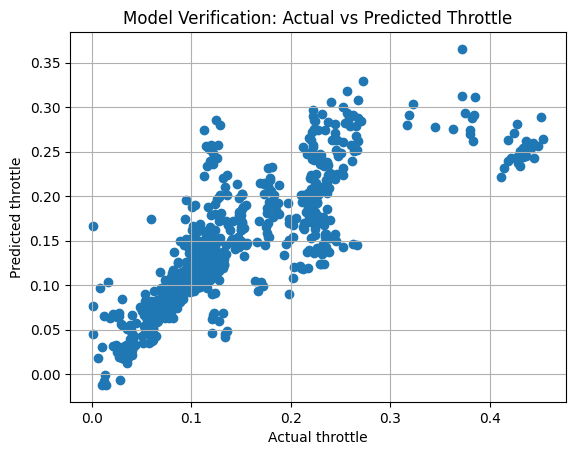

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Load CSV
df = pd.read_csv("speedvsAccvsThrottle.csv")
X = df[['acceleration', 'speed']].values
y = df['throttle'].values

# Load your trained model
model = LinearRegression()
degree = 2
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)
model.fit(X_poly, y)

# Predict
y_pred = model.predict(X_poly)

# Scatter plot: actual vs predicted
plt.scatter(y, y_pred)
plt.xlabel("Actual throttle")
plt.ylabel("Predicted throttle")
plt.title("Model Verification: Actual vs Predicted Throttle")
plt.grid(True)
plt.show()


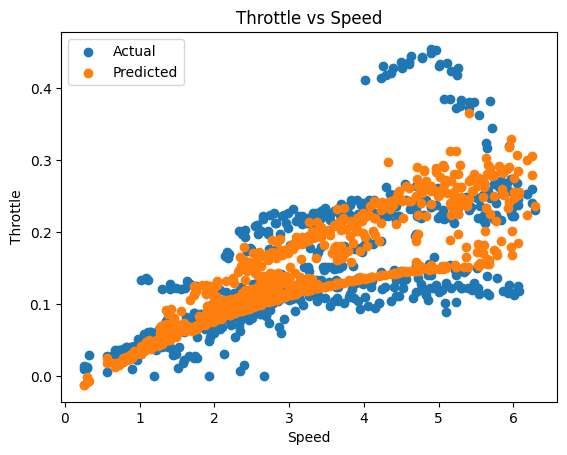

In [ ]:
plt.scatter(df['speed'], y, label='Actual')
plt.scatter(df['speed'], y_pred, label='Predicted')
plt.xlabel("Speed")
plt.ylabel("Throttle")
plt.legend()
plt.title("Throttle vs Speed")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² score:", r2)


MSE: 0.0024047489091492875
RMSE: 0.049038239254170696
R² score: 0.6670102560766147


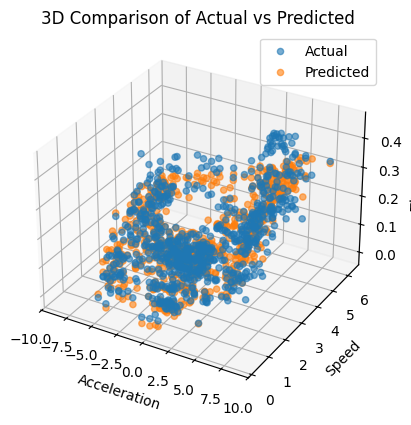

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['acceleration'], df['speed'], y, label='Actual', alpha=0.6)
ax.scatter(df['acceleration'], df['speed'], y_pred, label='Predicted', alpha=0.6)

ax.set_xlabel("Acceleration")
ax.set_ylabel("Speed")
ax.set_zlabel("Throttle")
plt.title("3D Comparison of Actual vs Predicted")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# Load CSV
df = pd.read_csv("speedvsAccvsThrottle.csv")

# Apply Gaussian smoothing to throttle
sigma = 3   # adjust smoothness (2–6 works well)
df['throttle_smooth'] = gaussian_filter1d(df['throttle'], sigma=sigma)

df.head()


,elapsed time,acceleration,throttle,speed,throttle_smooth
0,0.380,-5.110201,0.230,3.4594,0.176007
1,0.432,4.090202,0.237,3.7000,0.170144
2,0.493,3.311598,0.129,3.8948,0.159782
3,0.549,-6.694600,0.125,3.5010,0.147176
4,0.606,-4.450597,0.118,3.2392,0.134773


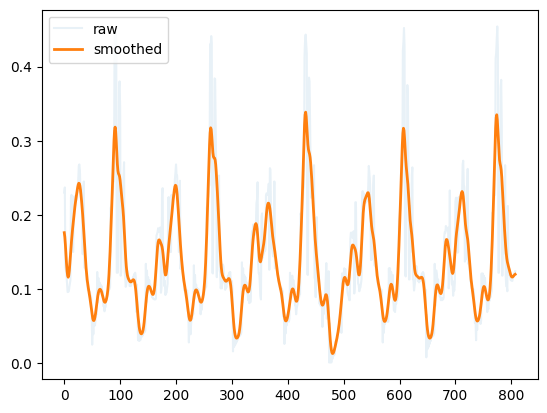

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['throttle'], label="raw", alpha=0.1)
plt.plot(df['throttle_smooth'], label="smoothed", linewidth=2)
plt.legend()
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import joblib

X = df[['acceleration', 'speed']].values
y = df['throttle_smooth'].values

degree = 2
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

joblib.dump((model.coef_, model.intercept_, degree), "poly2_smoothed.pkl")

print("Model trained on smoothed throttle.")
print("coef size:", len(model.coef_))


Model trained on smoothed throttle.
coef size: 6


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_poly)

print("MSE:", mean_squared_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R² score:", r2_score(y, y_pred))


MSE: 0.0010465563464757907
RMSE: 0.032350523125226134
R² score: 0.7799997605473976


In [ ]:
coef, intercept, degree = joblib.load("poly2_smoothed.pkl")

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree)
poly.fit(np.zeros((1,2)))  # just to get feature names

feature_names = poly.get_feature_names_out(['a', 'v'])

cpp_code = generate_cpp_poly_2d(coef, intercept, feature_names)

with open("throttle_model.cpp", "w") as f:
    f.write(cpp_code)

print(cpp_code)

double throttle_from_acc_speed(double a, double v) {
    return -0.012833251448 + (0.002944490101 * (a)) + (0.057379678892 * (v)) + (0.000328776471 * (a^2)) + (0.000533089661 * (a v)) + (-0.002773426265 * (v^2));
}



In [ ]:
df['acceleration'].max()

8.74139595031738

In [ ]:
df['speed'].max()

6.28399991989136